# Market Basket Analysis — Data Preprocessing

## Step 1 — Load & Inspect Data

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import pickle
from mlxtend.preprocessing import TransactionEncoder

path = kagglehub.dataset_download("heeraldedhia/groceries-dataset")
file_path = os.path.join(path, "Groceries_dataset.csv")
df = pd.read_csv(file_path)

print(f"Data Loaded. Shape: {df.shape}")

Using Colab cache for faster access to the 'groceries-dataset' dataset.
Data Loaded. Shape: (38765, 3)


## Step 2 — Data Cleaning

In [29]:
# Standardize Date and Item Names
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['itemDescription'] = df['itemDescription'].str.strip().str.lower()

# Remove exact duplicates
df_clean = df.drop_duplicates().reset_index(drop=True)

# Create Transaction ID (Grouping by Member and Date)
df_clean['transaction_id'] = (
    df_clean['Member_number'].astype(str) + '_' +
    df_clean['Date'].dt.strftime('%Y%m%d')
)

print(f"Cleaning complete. Unique Transactions: {df_clean['transaction_id'].nunique()}")

Cleaning complete. Unique Transactions: 14963


## Step 3 — Exploratory Data Analysis (EDA)

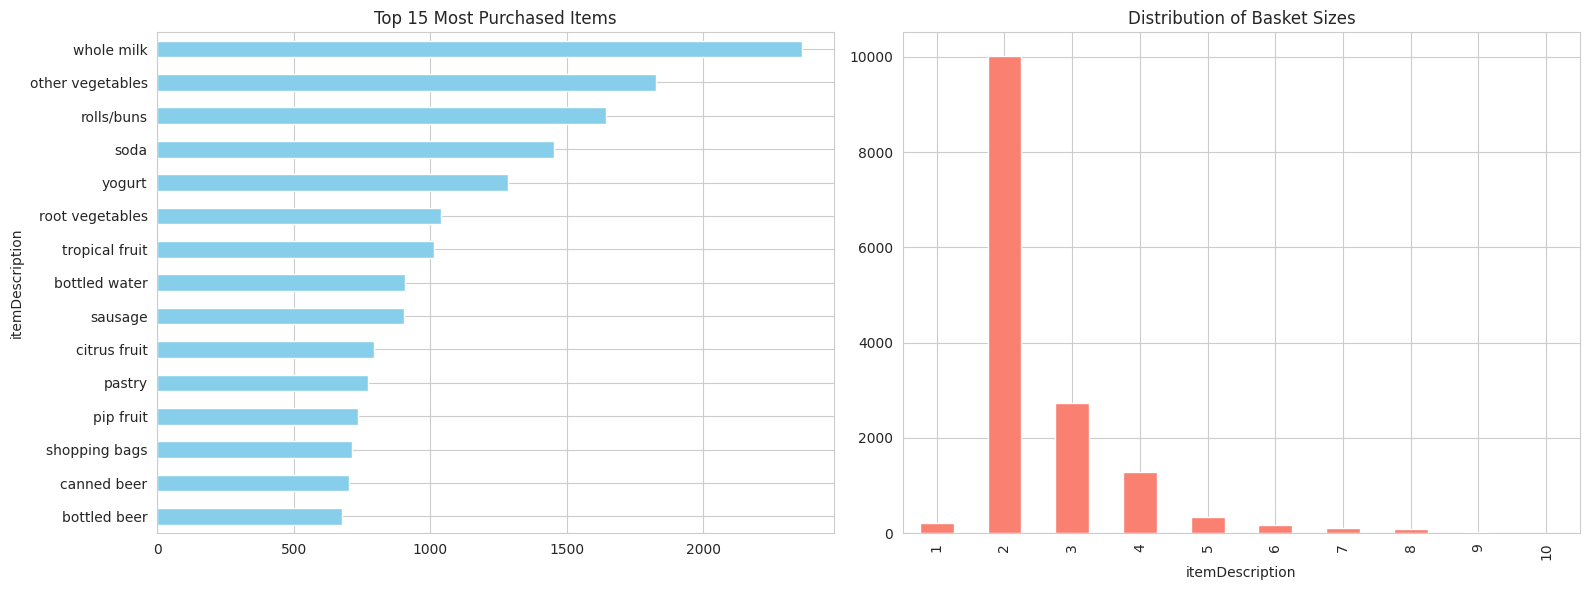

In [30]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Top 15 Items
df_clean['itemDescription'].value_counts().head(15).sort_values().plot(
    kind='barh', ax=axes[0], color='skyblue'
)
axes[0].set_title('Top 15 Most Purchased Items')

# Chart 2: Basket Size Distribution
basket_sizes = df_clean.groupby('transaction_id')['itemDescription'].count()
basket_sizes.value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='salmon'
)
axes[1].set_title('Distribution of Basket Sizes')

plt.tight_layout()
plt.show()

## Step 4 — Transform to Basket Format

In [31]:
# Format 1: List of lists (for FP-Growth)
transactions = df_clean.groupby('transaction_id')['itemDescription'].apply(list).tolist()

# Format 2: One-hot matrix (for Apriori)
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

print(f"Matrix ready. Shape: {basket_df.shape}")

Matrix ready. Shape: (14963, 167)


## Step 5 — Save Outputs

In [32]:
df_clean.to_csv('groceries_cleaned.csv', index=False)
basket_df.to_csv('basket_matrix.csv', index=False)

with open('transactions_list.pkl', 'wb') as f:
    pickle.dump(transactions, f)

print("Complete.")

✅ Preprocessing complete. 3 files exported for model training.
